In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

import joblib

In [2]:
DATA_PATH = Path("../data/raw/ai4i2020.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
print(df.columns.tolist())

df.info()

df.isnull().sum()

['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PW

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


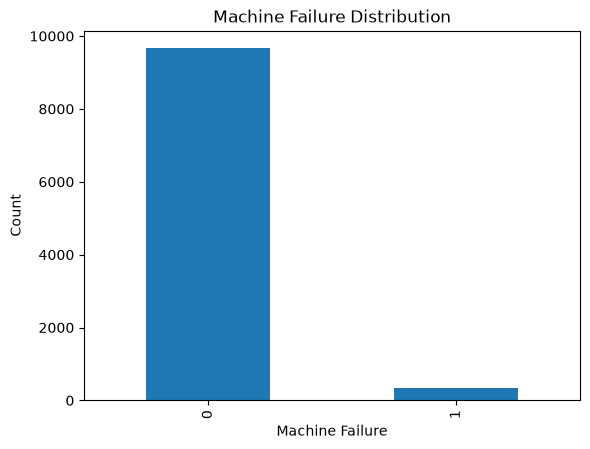

In [4]:
df["Machine failure"].value_counts()

failure_ratio = df["Machine failure"].value_counts(normalize=True)

print(failure_ratio)

df["Machine failure"].value_counts().plot(
    kind="bar",
    title="Machine Failure Distribution"
)

plt.xlabel("Machine Failure")
plt.ylabel("Count")
plt.show()

In [5]:
leakage_columns = [
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

df_model = df.drop(columns=leakage_columns)

df_model.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,1,M14860,M,298.1,308.6,1551,42.8,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0


In [6]:
feature_columns = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

target_column = "Machine failure"

X = df_model[feature_columns]
y = df_model[target_column]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (10000, 6)
y shape: (10000,)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

print("\nTrain failure rate:")
print(y_train.value_counts(normalize=True))

print("\nTest failure rate:")
print(y_test.value_counts(normalize=True))

Train size: 8000
Test size: 2000

Train failure rate:
Machine failure
0    0.966125
1    0.033875
Name: proportion, dtype: float64

Test failure rate:
Machine failure
0    0.966
1    0.034
Name: proportion, dtype: float64


In [8]:
categorical_features = ["Type"]

numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

In [10]:
rf_pipeline.fit(X_train, y_train)

print("Training complete.")

Training complete.


In [11]:
y_pred = rf_pipeline.predict(X_test)
y_prob = rf_pipeline.predict_proba(X_test)[:, 1]
print(y_prob[:10])

[0.35666667 0.         0.14333333 0.00666667 0.15333333 0.
 0.02       0.         0.         0.17333333]


In [12]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print(classification_report(y_test, y_pred, digits=4))

Accuracy : 0.9785
Precision: 0.6923
Recall   : 0.6618
F1 Score : 0.6767
ROC-AUC  : 0.9699
              precision    recall  f1-score   support

           0     0.9881    0.9896    0.9889      1932
           1     0.6923    0.6618    0.6767        68

    accuracy                         0.9785      2000
   macro avg     0.8402    0.8257    0.8328      2000
weighted avg     0.9781    0.9785    0.9783      2000



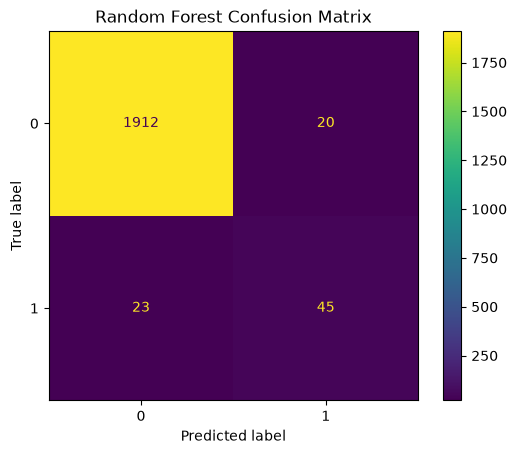

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Random Forest Confusion Matrix")
plt.show()

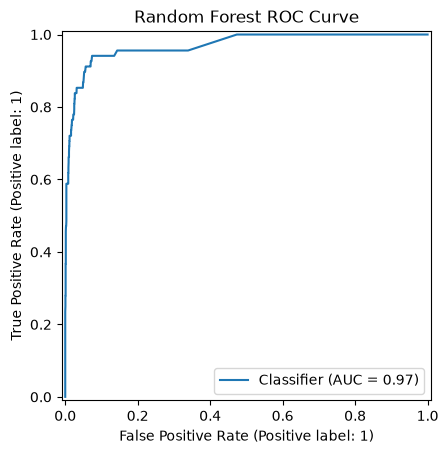

In [14]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Random Forest ROC Curve")
plt.show()

In [15]:
results = X_test.copy()

results["Actual Failure"] = y_test.values
results["Predicted Failure"] = y_pred
results["Failure Risk"] = y_prob

results.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Actual Failure,Predicted Failure,Failure Risk
2997,L,300.5,309.8,1345,62.7,153,0,0,0.356667
4871,L,303.7,312.4,1513,40.1,135,0,0,0.000000
3858,L,302.5,311.4,1559,37.6,209,0,0,0.143333
951,H,295.6,306.3,1509,35.8,60,0,0,0.006667
6463,H,300.5,310.0,1358,60.4,102,0,0,0.153333


In [16]:
results_sorted = results.sort_values(
    "Failure Risk",
    ascending=False
)

results_sorted.head(10)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Actual Failure,Predicted Failure,Failure Risk
1391,L,298.9,310.2,2737,8.8,142,1,1,0.940000
380,L,297.5,308.3,2564,12.8,127,1,1,0.923333
7011,L,300.5,310.5,2633,12.2,17,1,1,0.903333
4495,L,302.6,310.4,1359,57.2,67,1,1,0.900000
249,L,298.0,308.3,1405,56.2,218,1,1,0.900000
6078,L,300.8,310.7,1339,59.1,203,1,1,0.886667
4661,L,303.3,311.3,1350,48.1,32,1,1,0.883333
4427,M,302.4,310.1,1379,48.9,107,1,1,0.880000
248,L,298.0,308.3,1362,56.8,216,1,1,0.873333
6497,L,300.8,309.9,1312,65.3,192,1,1,0.866667


In [17]:
RISK_THRESHOLD = 0.50

high_risk_assets = results_sorted[
    results_sorted["Failure Risk"] >= RISK_THRESHOLD
].copy()

print("Number of high-risk assets:", len(high_risk_assets))

high_risk_assets.head(10)

Number of high-risk assets: 65


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Actual Failure,Predicted Failure,Failure Risk
1391,L,298.9,310.2,2737,8.8,142,1,1,0.940000
380,L,297.5,308.3,2564,12.8,127,1,1,0.923333
7011,L,300.5,310.5,2633,12.2,17,1,1,0.903333
4495,L,302.6,310.4,1359,57.2,67,1,1,0.900000
249,L,298.0,308.3,1405,56.2,218,1,1,0.900000
6078,L,300.8,310.7,1339,59.1,203,1,1,0.886667
4661,L,303.3,311.3,1350,48.1,32,1,1,0.883333
4427,M,302.4,310.1,1379,48.9,107,1,1,0.880000
248,L,298.0,308.3,1362,56.8,216,1,1,0.873333
6497,L,300.8,309.9,1312,65.3,192,1,1,0.866667


In [18]:
target_risks = [
    0.95,
    0.85,
    0.75,
    0.65,
    0.55,
    0.45,
    0.35,
    0.25,
    0.15,
    0.05
]

selected_indices = []
available_indices = set(results.index)

for target_risk in target_risks:
    selected_index = min(
        available_indices,
        key=lambda idx: abs(
            results.loc[idx, "Failure Risk"] - target_risk
        )
    )

    selected_indices.append(selected_index)
    available_indices.remove(selected_index)


top_assets = results.loc[selected_indices].copy()

# Keep the original dataset row for traceability
top_assets["Source Row"] = top_assets.index

# Map selected observations to simulated factory assets
top_assets["Asset ID"] = [
    f"M{i:02d}" for i in range(1, len(top_assets) + 1)
]

top_assets[
    [
        "Asset ID",
        "Source Row",
        "Type",
        "Failure Risk",
        "Torque [Nm]",
        "Tool wear [min]"
    ]
]

,Asset ID,Source Row,Type,Failure Risk,Torque [Nm],Tool wear [min]
1391,M01,1391,L,0.940000,8.8,142
2444,M02,2444,L,0.853333,68.2,76
5706,M03,5706,L,0.760000,70.0,139
8846,M04,8846,M,0.656667,62.4,204
5701,M05,5701,M,0.550000,54.3,125
4283,M06,4283,M,0.450000,61.0,182
4028,M07,4028,L,0.353333,43.2,220
4466,M08,4466,L,0.246667,41.1,205
2856,M09,2856,H,0.146667,45.2,223
9482,M10,9482,H,0.050000,57.4,185


In [19]:
def assign_risk_level(probability):
    if probability >= 0.80:
        return "CRITICAL"
    elif probability >= 0.60:
        return "HIGH"
    elif probability >= 0.40:
        return "MEDIUM"
    else:
        return "LOW"


top_assets["Risk Level"] = top_assets["Failure Risk"].apply(
    assign_risk_level
)

top_assets[
    [
        "Asset ID",
        "Failure Risk",
        "Risk Level"
    ]
]

,Asset ID,Failure Risk,Risk Level
1391,M01,0.940000,CRITICAL
2444,M02,0.853333,CRITICAL
5706,M03,0.760000,HIGH
8846,M04,0.656667,HIGH
5701,M05,0.550000,MEDIUM
4283,M06,0.450000,MEDIUM
4028,M07,0.353333,LOW
4466,M08,0.246667,LOW
2856,M09,0.146667,LOW
9482,M10,0.050000,LOW


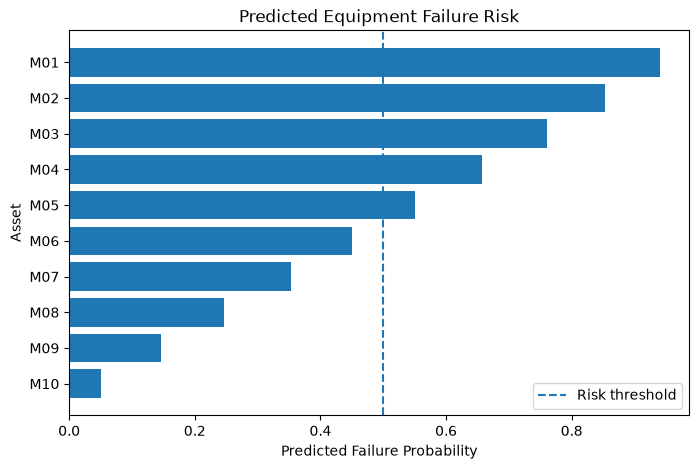

In [20]:
plot_data = top_assets.sort_values(
    "Failure Risk",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_data["Asset ID"],
    plot_data["Failure Risk"]
)

plt.axvline(
    0.5,
    linestyle="--",
    label="Risk threshold"
)

plt.xlabel("Predicted Failure Probability")
plt.ylabel("Asset")
plt.title("Predicted Equipment Failure Risk")
plt.legend()

plt.show()

In [21]:
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(
    rf_pipeline,
    MODEL_DIR / "random_forest_baseline.joblib"
)

print("Model saved.")

Model saved.


In [22]:
OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

routing_assets = top_assets[
    [
        "Asset ID",
        "Source Row",
        "Failure Risk",
        "Risk Level"
    ]
].copy()

routing_assets.to_csv(
    OUTPUT_DIR / "asset_failure_risks.csv",
    index=False
)

routing_assets

,Asset ID,Source Row,Failure Risk,Risk Level
1391,M01,1391,0.940000,CRITICAL
2444,M02,2444,0.853333,CRITICAL
5706,M03,5706,0.760000,HIGH
8846,M04,8846,0.656667,HIGH
5701,M05,5701,0.550000,MEDIUM
4283,M06,4283,0.450000,MEDIUM
4028,M07,4028,0.353333,LOW
4466,M08,4466,0.246667,LOW
2856,M09,2856,0.146667,LOW
9482,M10,9482,0.050000,LOW
